# Two-Electron 2D Schrödinger Solver — DVR / CI / RL


| Section | Content |
|:--------|:--------|
| 0 | Imports and physical parameters |
| 1 | Discrete Variable Representation (DVR) |
| 2 | Double-well potential |
| 3 | Single-particle eigenstates |
| 4 | Slater-determinant basis (energy-sorted — bug fix) |
| 5 | Coulomb kernel |
| 6 | CI Hamiltonian and two-electron spectrum |
| 7 | Spin, entanglement and orbital localisation |
| 8 | Model-aware RL (Belliardo et al. 2024) |

> **Bug fixed in this version:** the original code used an index-ordered Slater basis
> truncated at `n_compute = 40`, silently excluding all `(L_excited, R)` configurations
> such as `(L1, R0)`, `(L2, R0)` even though their one-body energy matches included
> `(L0, R_excited)` states.  The fix — `build_slater_basis_sorted` +
> `N_CI_COMPUTE = 200` — is demonstrated in Section 4.


---
## Section 0 — Imports and Physical Parameters

In [1]:
%matplotlib inline
import numpy as np
from scipy.linalg import eigh
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Physical / grid parameters (same as main())
Nx, Ny   = 20, 20
x0, xL   = -1.0,  1.0
y0, yL   = -0.5,  0.5
params   = {'a': 0.6, 'k': 1000.0, 'ky': 1500.0, 'delta': 5.0, 'd': 1.0}
kappa    = 2326.0    # Coulomb strength (Mott-Hubbard crossover, U/t ~ 1)
epsilon  = 0.01       # Coulomb softening length
Nstates  = 40        # SP orbitals to retain

print(f"Grid     : {Nx}x{Ny} = {Nx*Ny} points  [{x0},{xL}] x [{y0},{yL}]")
print(f"kappa    : {kappa}")
print(f"epsilon  : {epsilon}")
print(f"Nstates  : {Nstates}")


Grid     : 20x20 = 400 points  [-1.0,1.0] x [-0.5,0.5]
kappa    : 2326.0
epsilon  : 0.01
Nstates  : 40


---
## Section 1 — Discrete Variable Representation (DVR)

The sine-DVR maps $[x_0, x_L]$ onto $N$ grid points and returns the exact
kinetic-energy matrix in the DVR basis.  The 2-D kinetic matrix is a
Kronecker sum:

$$T_{2D} = T_x \otimes I_y + I_x \otimes T_y$$


In [2]:
def sine_dvr_1d(x0, xL, N):
    """1-D sine-DVR on [x0, xL] with N grid points.  hbar^2/2m = 1."""
    L = xL - x0
    x = x0 + np.arange(1, N + 1) * L / (N + 1)
    w = np.full(N, L / (N + 1))
    j = np.arange(1, N + 1)
    U = np.sqrt(2 / (N + 1)) * np.sin(np.outer(j, j * np.pi / (N + 1)))
    T = (U.T * (j * np.pi / L) ** 2) @ U
    return x, w, T


def build_2d_dvr(Nx=20, Ny=20, x0=-1.0, xL=1.0, y0=-0.5, yL=0.5):
    xg, wx, Tx = sine_dvr_1d(x0, xL, Nx)
    yg, wy, Ty = sine_dvr_1d(y0, yL, Ny)
    T2D = np.kron(Tx, np.eye(Ny)) + np.kron(np.eye(Nx), Ty)
    return xg, yg, wx, wy, T2D


x_grid, y_grid, w_x, w_y, T2D = build_2d_dvr(Nx, Ny, x0, xL, y0, yL)
print(f"DVR grid : {Nx}x{Ny} = {Nx*Ny} points")
print(f"T2D shape: {T2D.shape}")


DVR grid : 20x20 = 400 points
T2D shape: (400, 400)


---
## Section 2 — Double-Well Potential

$$V(x,y) = k\left[\left(\frac{x}{d}\right)^2 - a^2\right]^2
           + \delta\,x + \tfrac{1}{2}k_y\,y^2$$

Wells sit at $x = \pm a\,d$.  The linear tilt $\delta$ introduces asymmetry.


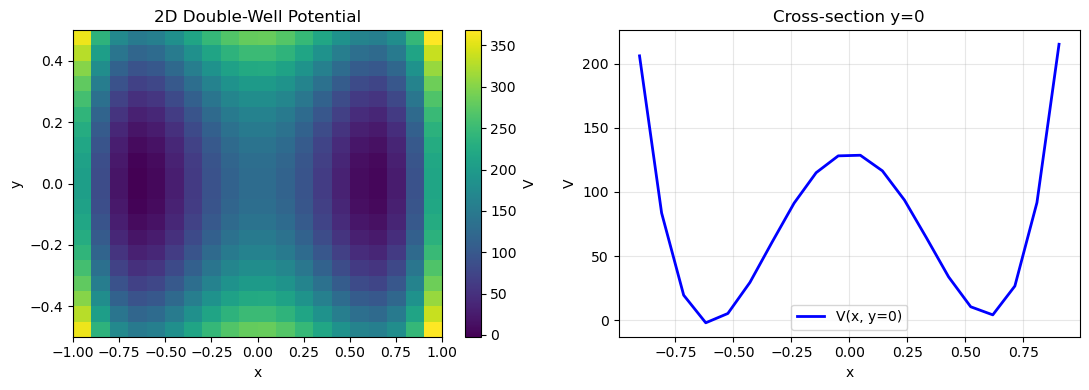

Well minima at x = +/-0.600


In [3]:
def double_well_potential(x, y, params):
    a     = params.get('a',     1.0)
    k     = params.get('k',    50.0)
    ky    = params.get('ky',  100.0)
    delta = params.get('delta', 0.5)
    d     = params.get('d',     1.0)
    return k * ((x / d)**2 - a**2)**2 + delta * x + 0.5 * ky * y**2


def build_potential_matrix(x_grid, y_grid, params):
    X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
    V    = double_well_potential(X, Y, params).ravel()
    return np.diag(V)


V2D = build_potential_matrix(x_grid, y_grid, params)

X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
V2d  = double_well_potential(X, Y, params)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
im = ax1.imshow(V2d.T, origin='lower', extent=(x0, xL, y0, yL), aspect='auto', cmap='viridis')
plt.colorbar(im, ax=ax1, label='V')
ax1.set(title='2D Double-Well Potential', xlabel='x', ylabel='y')
ax2.plot(x_grid, V2d[:, Ny // 2], 'b-', lw=2, label='V(x, y=0)')
ax2.set(title='Cross-section y=0', xlabel='x', ylabel='V')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nb_potential.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Well minima at x = +/-{params['a'] * params['d']:.3f}")


---
## Section 3 — Single-Particle Eigenstates

Diagonalise $H_{sp} = T_{2D} + V_{2D}$ for the single-electron spectrum
$\varepsilon_k$, $\psi_k$.


In [4]:
def single_particle_eigenstates(T2D, V2D, Nstates=40):
    e_vals, e_vecs = eigh(T2D + V2D)
    return e_vals[:Nstates], e_vecs[:, :Nstates]


print("Diagonalising single-particle Hamiltonian...")
single_energies, single_vecs = single_particle_eigenstates(T2D, V2D, Nstates)

print("\nLowest 10 single-particle energies:")
for i, e in enumerate(single_energies[:10]):
    print(f"  psi_{i:2d}  E = {e:10.4f}")


Diagonalising single-particle Hamiltonian...

Lowest 10 single-particle energies:
  psi_ 0  E =    61.1821
  psi_ 1  E =    66.8023
  psi_ 2  E =   117.5952
  psi_ 3  E =   123.2154
  psi_ 4  E =   126.2489
  psi_ 5  E =   131.8859
  psi_ 6  E =   170.4614
  psi_ 7  E =   179.5784
  psi_ 8  E =   182.6620
  psi_ 9  E =   185.1986


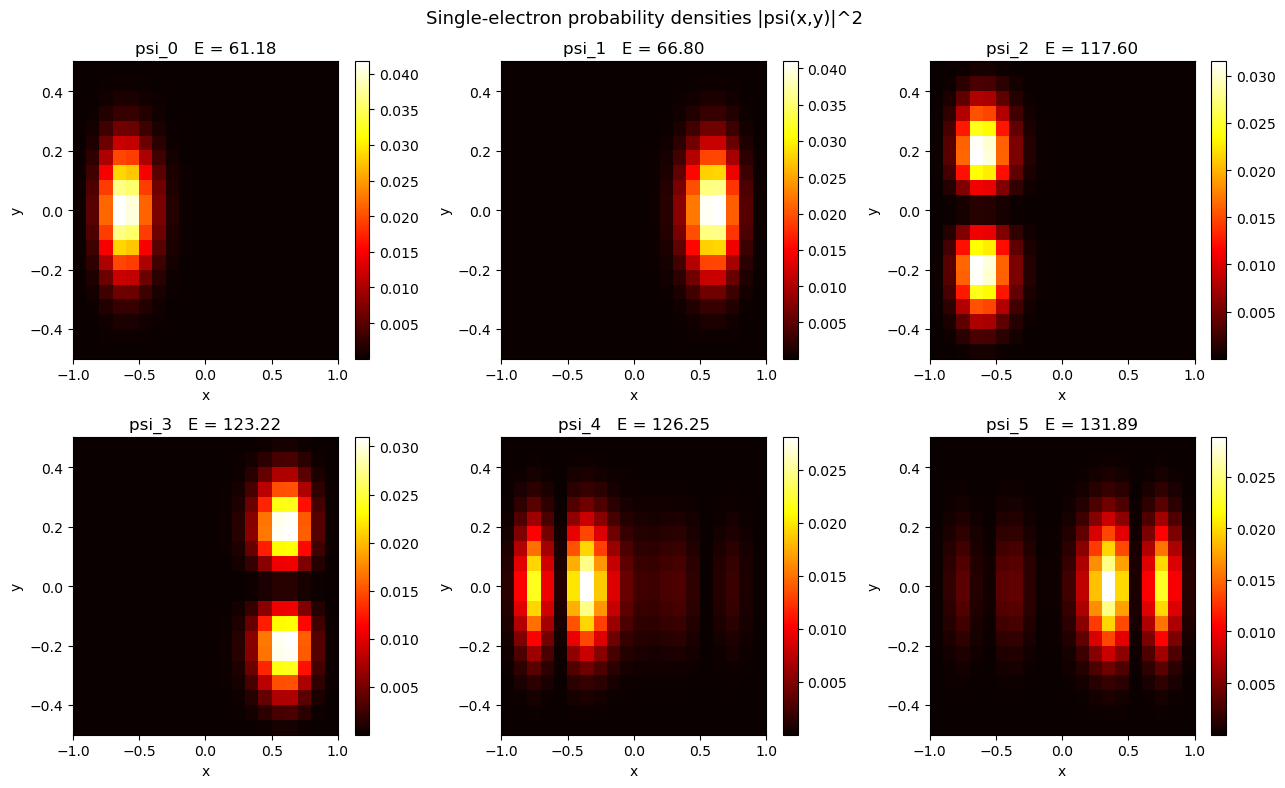

In [5]:
# Plot |psi|^2 for lowest 6 states
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for i, ax in enumerate(axes.flatten()):
    Z  = single_vecs[:, i].reshape(Nx, Ny)**2
    im = ax.imshow(Z.T, origin='lower', extent=(x0, xL, y0, yL), aspect='auto', cmap='hot')
    ax.set(title=f'psi_{i}   E = {single_energies[i]:.2f}', xlabel='x', ylabel='y')
    plt.colorbar(im, ax=ax)
plt.suptitle("Single-electron probability densities |psi(x,y)|^2", fontsize=13)
plt.tight_layout()
plt.savefig('nb_sp_states.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 4 — Slater-Determinant Basis (energy-sorted — bug fix)

### The original bug

`build_slater_basis()` ordered pairs as `(0,0),(0,1),...,(0,Nb-1),(1,1),(1,2),...`
so truncating to `n_compute = 40` kept only pairs involving orbital 0.
In the double-well this meant every `(L_excited, R)` configuration —
`(L1,R0)`, `(L2,R0)`, … — was absent from the CI despite having the same
one-body energy as the included `(L0, R_excited)` states.

| Basis index (old) | Config | $E_a+E_b$ | In n=40? |
|:---:|:---:|:---:|:---:|
| 1 | (L0, R0) | 128 | YES |
| 37 | (L0, R4) | 249 | YES (last) |
| **158** | **(L1, R0)** | **184** | **NO — cut off** |
| **166** | **(L2, R0)** | **193** | **NO — cut off** |

### The fix

`build_slater_basis_sorted()` sorts by $E_a+E_b$ so all configurations
in the energy window enter the CI regardless of orbital index.
`N_CI_COMPUTE = 200` covers L0–L4 × R0–R4 comfortably.


In [6]:
def build_slater_basis(Nb):
    """Original index-ordered basis (kept for reference/backward compatibility)."""
    basis = []
    for a in range(Nb):
        for b in range(a, Nb):
            if a == b:
                basis.append((a, b, 'ud', 'singlet'))
            else:
                basis.append((a, b, 'singlet',   'singlet'))
                basis.append((a, b, 'uu',         'triplet_p'))
                basis.append((a, b, 'triplet_0',  'triplet_0'))
                basis.append((a, b, 'dd',         'triplet_m'))
    return basis


def build_slater_basis_sorted(Nb, single_energies):
    """
    Energy-sorted Slater basis.

    Sorts all (a,b) orbital pairs by E_a + E_b before returning, so that
    truncating to n_compute determinants captures all configurations in
    the lowest energy window -- including L-excited (1,1) states such as
    (L1,R0) that the index-ordered basis placed at index >= 158.
    """
    raw = []
    for a in range(Nb):
        for b in range(a, Nb):
            Eab = float(single_energies[a]) + float(single_energies[b])
            if a == b:
                raw.append((Eab, a, b, 'ud',        'singlet'))
            else:
                raw.append((Eab, a, b, 'singlet',   'singlet'))
                raw.append((Eab, a, b, 'uu',        'triplet_p'))
                raw.append((Eab, a, b, 'triplet_0', 'triplet_0'))
                raw.append((Eab, a, b, 'dd',        'triplet_m'))
    raw.sort(key=lambda x: (x[0], x[1], x[2]))
    return [(a, b, sc, st) for (_, a, b, sc, st) in raw]


N_CI_COMPUTE  = 200   # raised from 40; covers L0-L4 x R0-R4

old_basis    = build_slater_basis(Nstates)
sorted_basis = build_slater_basis_sorted(Nstates, single_energies)

print(f"Full basis size              : {len(old_basis)}")
print(f"n_compute used               : {N_CI_COMPUTE}")
print()
print("First 10 entries of energy-sorted basis:")
for i, (a, b, sc, st) in enumerate(sorted_basis[:10]):
    Eab = single_energies[a] + single_energies[b]
    print(f"  [{i:3d}]  ({a:2d},{b:2d})  {st:<12}  E_a+E_b = {Eab:.2f}")


Full basis size              : 3160
n_compute used               : 200

First 10 entries of energy-sorted basis:
  [  0]  ( 0, 0)  singlet       E_a+E_b = 122.36
  [  1]  ( 0, 1)  singlet       E_a+E_b = 127.98
  [  2]  ( 0, 1)  triplet_p     E_a+E_b = 127.98
  [  3]  ( 0, 1)  triplet_0     E_a+E_b = 127.98
  [  4]  ( 0, 1)  triplet_m     E_a+E_b = 127.98
  [  5]  ( 1, 1)  singlet       E_a+E_b = 133.60
  [  6]  ( 0, 2)  singlet       E_a+E_b = 178.78
  [  7]  ( 0, 2)  triplet_p     E_a+E_b = 178.78
  [  8]  ( 0, 2)  triplet_0     E_a+E_b = 178.78
  [  9]  ( 0, 2)  triplet_m     E_a+E_b = 178.78


In [7]:
# Orbital localisation helper (needed to show L-rank in demo below)
def orbital_localization(single_vecs, single_energies, x_grid, y_grid,
                          Nstates=40, loc_threshold=0.20):
    Nx, Ny = len(x_grid), len(y_grid)
    X2d, _ = np.meshgrid(x_grid, y_grid, indexing='ij')
    Xf     = X2d.ravel()
    prob   = single_vecs[:, :Nstates]**2
    ex_all = Xf @ prob
    info   = []
    for idx in range(Nstates):
        ex = float(ex_all[idx])
        if   ex < -loc_threshold: label, wc = "Left well",   'L'
        elif ex >  loc_threshold: label, wc = "Right well",  'R'
        else:                     label, wc = "Delocalized", 'D'
        info.append((idx, float(single_energies[idx]), ex, label, wc))
    return info


orbital_info = orbital_localization(single_vecs, single_energies,
                                     x_grid, y_grid, Nstates)
well   = {o[0]: o[4] for o in orbital_info}
L_orbs = sorted([o[0] for o in orbital_info if o[4]=='L'], key=lambda i: single_energies[i])
R_orbs = sorted([o[0] for o in orbital_info if o[4]=='R'], key=lambda i: single_energies[i])
rank_L = {orb: k for k, orb in enumerate(L_orbs)}
rank_R = {orb: k for k, orb in enumerate(R_orbs)}

print(f"L orbitals: {[f'L{k}=psi{orb}(E={single_energies[orb]:.1f})' for k,orb in enumerate(L_orbs[:5])]}")
print(f"R orbitals: {[f'R{k}=psi{orb}(E={single_energies[orb]:.1f})' for k,orb in enumerate(R_orbs[:5])]}")
print()

# Compare how the first (1,1) singlets appear in each ordering
print("First (1,1) singlets in each basis ordering:")
print(f"  {'Basis':>12}  {'Index':>6}  {'Config':>10}  {'E_a+E_b':>10}  In n=40?")
print("  " + "-"*52)
for bname, basis in [("index-ord.", old_basis), ("energy-sort", sorted_basis)]:
    shown = 0
    for idx, (a, b, sc, st) in enumerate(basis):
        if st != 'singlet': continue
        wa = well.get(a, 'D'); wb = well.get(b, 'D')
        if not ((wa=='L' and wb=='R') or (wa=='R' and wb=='L')): continue
        la = rank_L.get(a if wa=='L' else b, -1)
        Eab = single_energies[a] + single_energies[b]
        flag = "YES" if idx < 40 else "NO"
        print(f"  {bname:>12}  {idx:>6}  L{la}-R?  {Eab:>10.2f}  {flag}")
        shown += 1
        if shown >= 5: break


L orbitals: ['L0=psi0(E=61.2)', 'L1=psi2(E=117.6)', 'L2=psi4(E=126.2)', 'L3=psi7(E=179.6)', 'L4=psi8(E=182.7)']
R orbitals: ['R0=psi1(E=66.8)', 'R1=psi3(E=123.2)', 'R2=psi5(E=131.9)', 'R3=psi9(E=185.2)', 'R4=psi10(E=188.3)']

First (1,1) singlets in each basis ordering:
         Basis   Index      Config     E_a+E_b  In n=40?
  ----------------------------------------------------
    index-ord.       1  L0-R?      127.98  YES
    index-ord.       9  L0-R?      184.40  YES
    index-ord.      17  L0-R?      193.07  YES
    index-ord.      33  L0-R?      246.38  YES
    index-ord.      37  L0-R?      249.48  YES
   energy-sort       1  L0-R?      127.98  YES
   energy-sort      10  L1-R?      184.40  YES
   energy-sort      14  L0-R?      184.40  YES
   energy-sort      26  L2-R?      193.05  YES
   energy-sort      30  L0-R?      193.07  YES


---
## Section 5 — Coulomb Kernel

$$K[g_1, g_2] = \frac{w_{g_1}\,w_{g_2}\,\kappa}
                      {\sqrt{|\mathbf{r}_1-\mathbf{r}_2|^2+\varepsilon^2}}$$

Precomputed once as a $(G\times G)$ matrix.  All two-electron integrals
$(ac|bd)$ are then matrix-vector products against $K$.


In [8]:
def precompute_coulomb_kernel(x_grid, y_grid, wx, wy, kappa=1.0, epsilon=0.1):
    X, Y    = np.meshgrid(x_grid, y_grid, indexing='ij')
    Xf, Yf  = X.ravel(), Y.ravel()
    Wx, Wy  = np.meshgrid(wx, wy, indexing='ij')
    Wf      = (Wx * Wy).ravel()
    dx = Xf[:, None] - Xf[None, :]
    dy = Yf[:, None] - Yf[None, :]
    r12 = np.sqrt(dx**2 + dy**2 + epsilon**2)
    return kappa / r12 * Wf[:, None] * Wf[None, :]


print(f"Building Coulomb kernel (kappa={kappa}, epsilon={epsilon})...")
K = precompute_coulomb_kernel(x_grid, y_grid, w_x, w_y, kappa, epsilon)
print(f"K shape : {K.shape}  ({K.nbytes / 1e6:.1f} MB)")
print(f"K range : [{K.min():.3e}, {K.max():.3e}]")


Building Coulomb kernel (kappa=2326.0, epsilon=0.01)...
K shape : (400, 400)  (1.3 MB)
K range : [2.365e-02, 4.784e+00]


---
## Section 6 — CI Hamiltonian and Two-Electron Spectrum

Slater–Condon matrix element rules (Szabo & Ostlund §2.3):

| Element | Formula |
|:--------|:--------|
| $\langle aa\,S \| V \| aa\,S \rangle$ | $J(a,a)$ |
| $\langle ab\,S \| V \| ab\,S \rangle$ | $J(a,b)+K(a,b)$ |
| $\langle ab\,T \| V \| ab\,T \rangle$ | $J(a,b)-K(a,b)$ |
| $\langle aa\,S \| V \| bb\,S \rangle$ | $K_{ex}(a,b)$ |
| $\langle aa\,S \| V \| cd\,S \rangle$ | $\frac{1}{\sqrt{2}}(ac|ad)$ |
| $\langle ab\,S \| V \| cd\,S \rangle$ | $(ac|bd)+(ad|bc)$ |
| $\langle ab\,T \| V \| cd\,T \rangle$ | $(ac|bd)-(ad|bc)$ |


In [9]:
def build_ci_hamiltonian(slater_basis, single_energies, sv, K, n_compute=40):
    n  = min(n_compute, len(slater_basis))
    H  = np.zeros((n, n))
    _te_cache = {}
    def te(a, b, c, d):
        key = (a, b, c, d)
        if key not in _te_cache:
            _te_cache[key] = float((sv[:, a] * sv[:, c]) @ K @ (sv[:, b] * sv[:, d]))
        return _te_cache[key]

    for I in range(n):
        a_I, b_I, _, stype_I = slater_basis[I]
        same_I = (a_I == b_I)
        for J in range(I, n):
            a_J, b_J, _, stype_J = slater_basis[J]
            if stype_I != stype_J: continue
            same_J = (a_J == b_J); val = 0.0
            if I == J:
                val += single_energies[a_I] + single_energies[b_I]
            if stype_I == 'singlet':
                if same_I and same_J:
                    if a_I == a_J: val += te(a_I, a_I, a_I, a_I)
                    else:          val += 2.0 * te(a_I, a_J, a_I, a_J)
                elif same_I:  val += np.sqrt(2.0) * te(a_I, a_J, a_I, b_J)
                elif same_J:  val += np.sqrt(2.0) * te(a_I, a_J, b_I, a_J)
                else:         val += te(a_I, a_J, b_I, b_J) + te(a_I, b_J, b_I, a_J)
            else:
                if not same_I and not same_J:
                    val += te(a_I, a_J, b_I, b_J) - te(a_I, b_J, b_I, a_J)
            H[I, J] += val
            if I != J: H[J, I] = H[I, J]
    return H


print(f"Building {N_CI_COMPUTE}x{N_CI_COMPUTE} CI Hamiltonian (energy-sorted basis)...")
slater_basis = build_slater_basis_sorted(Nstates, single_energies)
n_compute    = min(N_CI_COMPUTE, len(slater_basis))
H_slater     = build_ci_hamiltonian(slater_basis, single_energies,
                                     single_vecs, K, n_compute)
E2, C2 = eigh(H_slater)
print(f"Done.  n_compute = {n_compute},  lowest E = {E2[0]:.4f}")


Building 200x200 CI Hamiltonian (energy-sorted basis)...
Done.  n_compute = 200,  lowest E = 122.7426


In [10]:
# Config label helper
def cfg_label(a, b):
    wa = well.get(a, 'D'); wb = well.get(b, 'D')
    def lbl(idx, w):
        if w == 'L': return f"L{rank_L[idx]}"
        if w == 'R': return f"R{rank_R[idx]}"
        return f"D{idx}"
    return f"{lbl(a,wa)}-{lbl(b,wb)}"

_SPIN = {'singlet':(0.,0.),'triplet_p':(2.,1.),'triplet_0':(2.,0.),'triplet_m':(2.,-1.)}

print("Two-electron spectrum (lowest 20 states):")
print(f"  {'#':>3}  {'Energy':>10}  {'dE':>8}  {'Spin':>8}  {'Config':>10}")
print("  " + "-"*46)
for i in range(min(20, len(E2))):
    dom  = int(np.argmax(np.abs(C2[:, i])))
    a_d, b_d = slater_basis[dom][0], slater_basis[dom][1]
    S2   = sum(C2[:,i]**2 * [_SPIN[slater_basis[j][3]][0] for j in range(n_compute)])
    spin = 'Singlet' if S2 < 0.5 else 'Triplet'
    cfg  = cfg_label(a_d, b_d)
    print(f"  {i:>3}  {E2[i]:>10.4f}  {E2[i]-E2[0]:>8.4f}  {spin:>8}  {cfg:>10}")


Two-electron spectrum (lowest 20 states):
    #      Energy        dE      Spin      Config
  ----------------------------------------------
    0    122.7426    0.0000   Singlet       L0-L0
    1    127.9845    5.2419   Triplet       L0-R0
    2    127.9845    5.2419   Triplet       L0-R0
    3    127.9845    5.2419   Triplet       L0-R0
    4    127.9845    5.2419   Singlet       L0-R0
    5    133.9828   11.2402   Singlet       R0-R0
    6    178.7773   56.0348   Triplet       L0-L1
    7    178.7773   56.0348   Triplet       L0-L1
    8    178.7773   56.0348   Triplet       L0-L1
    9    179.0058   56.2632   Singlet       L0-L1
   10    184.3976   61.6550   Triplet       R0-L1
   11    184.3976   61.6550   Triplet       R0-L1
   12    184.3976   61.6550   Triplet       R0-L1
   13    184.3976   61.6550   Triplet       L0-R1
   14    184.3976   61.6550   Triplet       L0-R1
   15    184.3976   61.6550   Triplet       R0-L1
   16    184.3976   61.6550   Triplet       L0-R1
   17    

In [11]:
# Show all (1,1) states including L-excited ones
print("(1,1) states with L-electron orbital rank:")
print(f"  {'State':>6}  {'Energy':>8}  {'Spin':>8}  {'Config':>10}  dom.weight")
print("  " + "-"*50)
for i in range(n_compute):
    dom = int(np.argmax(np.abs(C2[:, i])))
    a_d, b_d, _, st_d = slater_basis[dom]
    wa = well.get(a_d,'D'); wb = well.get(b_d,'D')
    is11 = (wa=='L' and wb=='R') or (wa=='R' and wb=='L')
    if not is11: continue
    S2   = sum(C2[:,i]**2 * [_SPIN[slater_basis[j][3]][0] for j in range(n_compute)])
    spin = 'Singlet' if S2 < 0.5 else 'Triplet'
    cfg  = cfg_label(a_d, b_d)
    print(f"  {i:>6}  {E2[i]:>8.2f}  {spin:>8}  {cfg:>10}  {C2[dom,i]**2:.4f}")


(1,1) states with L-electron orbital rank:
   State    Energy      Spin      Config  dom.weight
  --------------------------------------------------
       1    127.98   Triplet       L0-R0  0.9637
       2    127.98   Triplet       L0-R0  0.6775
       3    127.98   Triplet       L0-R0  0.7079
       4    127.98   Singlet       L0-R0  1.0000
      10    184.40   Triplet       R0-L1  0.9078
      11    184.40   Triplet       R0-L1  0.6820
      12    184.40   Triplet       R0-L1  0.6307
      13    184.40   Triplet       L0-R1  0.3343
      14    184.40   Triplet       L0-R1  0.6177
      15    184.40   Triplet       R0-L1  0.3372
      16    184.40   Triplet       L0-R1  0.6714
      17    184.40   Singlet       L0-R1  0.5000
      26    193.05   Triplet       R0-L2  0.9085
      27    193.05   Triplet       R0-L2  0.9813
      28    193.05   Triplet       R0-L2  0.9141
      29    193.07   Singlet       R0-L2  0.9997
      30    193.07   Triplet       L0-R2  0.9999
      31    193.07

---
## Section 7 — Spin, Entanglement and Orbital Localisation

For each two-electron CI eigenstate:
- $\langle S^2 \rangle$, $\langle S_z \rangle$ (spin character)
- Von Neumann entropy of the 1-RDM (entanglement)
- Well classification L/R/D from $\langle x \rangle$


In [12]:
# Orbital localisation printout
print("ORBITAL LOCALISATION")
print(f"  {'psi':>5} | {'Energy':>10} | {'<x>':>8} | Well")
print("  " + "-"*42)
for idx, en, ex, lbl, wc in orbital_info:
    print(f"  psi_{idx:2d} | {en:10.4f} | {ex:8.4f} | {lbl}")


ORBITAL LOCALISATION
    psi |     Energy |      <x> | Well
  ------------------------------------------
  psi_ 0 |    61.1821 |  -0.5642 | Left well
  psi_ 1 |    66.8023 |   0.5597 | Right well
  psi_ 2 |   117.5952 |  -0.5642 | Left well
  psi_ 3 |   123.2154 |   0.5597 | Right well
  psi_ 4 |   126.2489 |  -0.3572 | Left well
  psi_ 5 |   131.8859 |   0.3446 | Right well
  psi_ 6 |   170.4614 |  -0.0355 | Delocalized
  psi_ 7 |   179.5784 |  -0.5642 | Left well
  psi_ 8 |   182.6620 |  -0.3572 | Left well
  psi_ 9 |   185.1986 |   0.5597 | Right well
  psi_10 |   188.2990 |   0.3446 | Right well
  psi_11 |   194.5856 |   0.0158 | Delocalized
  psi_12 |   226.8745 |  -0.0355 | Delocalized
  psi_13 |   230.5981 |  -0.0006 | Delocalized
  psi_14 |   244.6452 |  -0.3572 | Left well
  psi_15 |   250.2822 |   0.3446 | Right well
  psi_16 |   250.9986 |   0.0158 | Delocalized
  psi_17 |   253.1776 |  -0.5642 | Left well
  psi_18 |   258.7978 |   0.5597 | Right well
  psi_19 |   269.9809 |

In [13]:
_SPIN_TABLE = {
    'singlet':   (0.0,  0.0),
    'triplet_p': (2.0,  1.0),
    'triplet_0': (2.0,  0.0),
    'triplet_m': (2.0, -1.0),
}

def compute_spin_and_entanglement(eigenstate_coeffs, slater_basis, Nb):
    """<S^2>, <Sz> and von Neumann entropy of the 1-RDM."""
    coeffs = np.asarray(eigenstate_coeffs)
    probs  = coeffs.real**2 + coeffs.imag**2
    S2 = Sz = 0.0
    for i, (_, _, _, st) in enumerate(slater_basis):
        s2, sz = _SPIN_TABLE.get(st, (0., 0.))
        S2 += probs[i] * s2; Sz += probs[i] * sz
    d   = 2 * Nb
    rho = np.zeros((d, d), dtype=complex)
    for i, c in enumerate(coeffs):
        if abs(c) < 1e-12: continue
        a, b, _, stype = slater_basis[i]
        ia_up, ia_dn = 2*a, 2*a+1
        ib_up, ib_dn = 2*b, 2*b+1
        if a == b:
            f = c / np.sqrt(2)
            rho[ia_up, ia_dn] += f; rho[ia_dn, ia_up] -= f
        elif stype == 'singlet':
            f = c / 2.
            rho[ia_up, ib_dn] += f; rho[ia_dn, ib_up] -= f
            rho[ib_up, ia_dn] += f; rho[ib_dn, ia_up] -= f
        elif stype == 'triplet_p':
            f = c / np.sqrt(2)
            rho[ia_up, ib_up] += f; rho[ib_up, ia_up] -= f
        elif stype == 'triplet_0':
            f = c / 2.
            rho[ia_up, ib_dn] += f; rho[ia_dn, ib_up] += f
            rho[ib_up, ia_dn] -= f; rho[ib_dn, ia_up] -= f
        elif stype == 'triplet_m':
            f = c / np.sqrt(2)
            rho[ia_dn, ib_dn] += f; rho[ib_dn, ia_dn] -= f
    rho1 = rho @ rho.conj().T
    eigv = np.linalg.eigvalsh(rho1.real)
    eigv = eigv[eigv > 1e-12]
    ent  = float(-np.dot(eigv, np.log(eigv))) if len(eigv) else 0.
    return S2, Sz, ent


In [14]:
# Spin + entanglement table and spectrum plot
print("Spin and entanglement (first 40 states):")
print(f"  {'#':>4} | {'Energy':>10} | {'<S2>':>6} | {'<Sz>':>6} | {'Entropy':>8} | {'Config':>10} | Type")
print("  " + "="*72)
spin_S2_values, spin_Sz_values, entropies = [], [], []
for n in range(min(n_compute, len(E2))):
    S2, Sz, S_ent = compute_spin_and_entanglement(
        C2[:, n], slater_basis[:n_compute], Nstates)
    spin_S2_values.append(S2); spin_Sz_values.append(Sz); entropies.append(S_ent)
    dom = int(np.argmax(np.abs(C2[:, n])))
    cfg = cfg_label(slater_basis[dom][0], slater_basis[dom][1])
    lbl = ("Singlet"       if abs(S2) < 0.1 else
           "Triplet Ms=+1" if abs(Sz - 1.) < 0.1 else
           "Triplet Ms=0"  if abs(Sz) < 0.1 else
           "Triplet Ms=-1" if abs(Sz + 1.) < 0.1 else "Mixed")
    print(f"  {n:>4} | {E2[n]:>10.4f} | {S2:>6.2f} | {Sz:>6.2f} | "
          f"{S_ent:>8.4f} | {cfg:>10} | {lbl}")


Spin and entanglement (first 40 states):
     # |     Energy |   <S2> |   <Sz> |  Entropy |     Config | Type
     0 |   122.7426 |   0.00 |  -0.00 |   0.6942 |      L0-L0 | Singlet
     1 |   127.9845 |   2.00 |  -0.93 |   0.8386 |      L0-R0 | Triplet Ms=-1
     2 |   127.9845 |   2.00 |   0.64 |   0.6938 |      L0-R0 | Mixed
     3 |   127.9845 |   2.00 |   0.29 |   1.0670 |      L0-R0 | Mixed
     4 |   127.9845 |   0.00 |   0.00 |   1.3863 |      L0-R0 | Singlet
     5 |   133.9828 |   0.00 |  -0.00 |   0.6942 |      R0-R0 | Singlet
     6 |   178.7773 |   2.00 |  -0.36 |   1.2770 |      L0-L1 | Mixed
     7 |   178.7773 |   2.00 |   0.18 |   1.3469 |      L0-L1 | Mixed
     8 |   178.7773 |   2.00 |   0.17 |   1.2392 |      L0-L1 | Mixed
     9 |   179.0058 |   0.00 |   0.00 |   1.3863 |      L0-L1 | Singlet
    10 |   184.3976 |   1.98 |  -0.86 |   1.0304 |      R0-L1 | Mixed
    11 |   184.3976 |   1.99 |   0.68 |   1.0674 |      R0-L1 | Mixed
    12 |   184.3976 |   1.97 |  -0

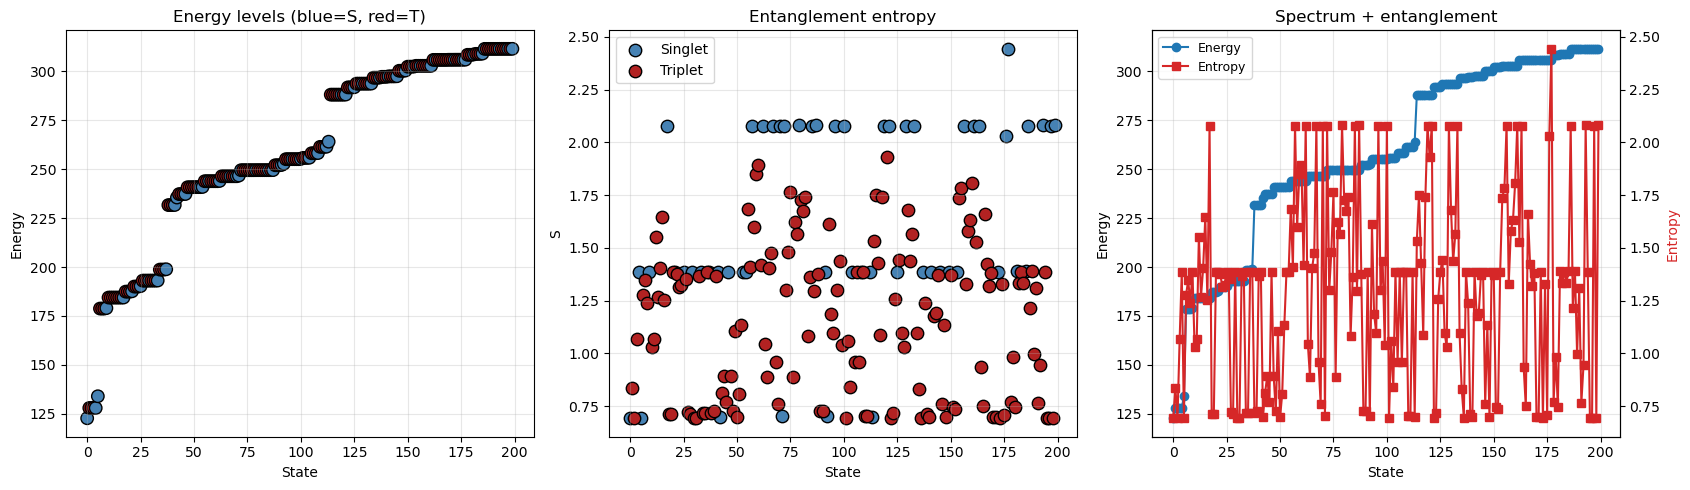

In [15]:
# Spectrum figure
n_plot  = min(len(E2), len(entropies))
idx_arr = np.arange(n_plot)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

colors = ['steelblue' if s < 0.5 else 'firebrick' for s in spin_S2_values[:n_plot]]
ax1.scatter(idx_arr, E2[:n_plot], c=colors, s=80, edgecolor='k', lw=1.0)
ax1.set(title='Energy levels (blue=S, red=T)', xlabel='State', ylabel='Energy')
ax1.grid(True, alpha=0.3)

sm = np.array(spin_S2_values[:n_plot]) < 0.5
if sm.any():
    ax2.scatter(idx_arr[sm],  np.array(entropies[:n_plot])[sm],
                c='steelblue', s=80, label='Singlet', edgecolor='k', lw=1.)
if (~sm).any():
    ax2.scatter(idx_arr[~sm], np.array(entropies[:n_plot])[~sm],
                c='firebrick', s=80, label='Triplet', edgecolor='k', lw=1.)
ax2.set(title='Entanglement entropy', xlabel='State', ylabel='S')
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3b = ax3.twinx()
ax3.plot(idx_arr, E2[:n_plot], 'o-', color='tab:blue', lw=1.5, label='Energy')
ax3b.plot(idx_arr, entropies[:n_plot], 's-', color='tab:red', lw=1.5, label='Entropy')
ax3.set(xlabel='State', ylabel='Energy')
ax3b.set_ylabel('Entropy', color='tab:red')
ax3.set_title('Spectrum + entanglement')
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labs1+labs2, fontsize=9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nb_spectrum.png', dpi=120, bbox_inches='tight')
plt.show()


In [16]:
def analyze_spin_character(C_slater, slater_basis, verbose=True):
    """Fraction of singlet vs triplet weight per eigenstate."""
    n_states = C_slater.shape[1]; purities = []
    for n in range(n_states):
        probs  = C_slater[:, n]**2
        s_mask = np.array([s[3] == 'singlet' for s in slater_basis])
        sp = float(probs[s_mask].sum()); tp = float(probs[~s_mask].sum())
        tot = sp + tp
        pur = (sp - tp) / tot if tot > 1e-10 else 0.
        purities.append(pur)
        if verbose and n < 40:
            lbl = ("Pure Singlet"   if pur >  0.9 else
                   "Mostly Singlet" if pur >  0.5 else
                   "Pure Triplet"   if pur < -0.9 else
                   "Mostly Triplet" if pur < -0.5 else "Mixed")
            print(f"State {n:2d}: purity = {pur:+.3f}  ->  {lbl}  "
                  f"(S:{sp:.1%}  T:{tp:.1%})")
    return np.array(purities)

print("Spin purity analysis:")
purities = analyze_spin_character(C2, slater_basis[:n_compute], verbose=True)


Spin purity analysis:
State  0: purity = +1.000  ->  Pure Singlet  (S:100.0%  T:0.0%)
State  1: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  2: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  3: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  4: purity = +1.000  ->  Pure Singlet  (S:100.0%  T:0.0%)
State  5: purity = +1.000  ->  Pure Singlet  (S:100.0%  T:0.0%)
State  6: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  7: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  8: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  9: purity = +1.000  ->  Pure Singlet  (S:100.0%  T:0.0%)
State 10: purity = -0.978  ->  Pure Triplet  (S:1.1%  T:98.9%)
State 11: purity = -0.989  ->  Pure Triplet  (S:0.5%  T:99.5%)
State 12: purity = -0.974  ->  Pure Triplet  (S:1.3%  T:98.7%)
State 13: purity = -0.443  ->  Mixed  (S:27.9%  T:72.1%)
State 14: purity = -0.966  ->  Pure Triplet  (S:1.7%  T:98.3%)
State 15: purity = +0.349  ->

---
## Section 8 — Model-Aware RL  (Belliardo et al., *Quantum* 2024)

Two optimisers run in parallel to maximise entanglement of (1,1)-localised states:

- **NN agent** — 5-layer tanh network conditioned on the quantum state vector;
  parameters updated via SPSA.
- **Direct gradient** — steepest descent with Adam directly on
  $\boldsymbol{\lambda} = (a, k, k_y, \delta, d)$.

Loss function:
$$\mathcal{L} = -\bar{S}_{ent}
               - \alpha_{gap}\,\Delta E_{ST}
               - \alpha_{tun}\,\ln(t+\epsilon)$$

> **Note:** the training cell runs the full 300-step loop (several minutes).
> Reduce `N_TRAIN_STEPS` for a quick test.


In [17]:
from concurrent.futures import ThreadPoolExecutor

N_TRAIN_STEPS = 300
LR_INIT       = 3e-3
ALPHA_GAP     = 0.05
ALPHA_TUNNEL  = 0.10
N_STATES_CI   = 40
LOC_THRESH    = 0.20
RL_SEED       = 42
N_WORKERS     = max(2, __import__('os').cpu_count() or 2)

PARAM_NAMES  = ['a', 'k', 'ky', 'delta', 'd']
PARAM_BOUNDS = {
    'a':     (0.30,  0.90), 'k':    (50.,  2000.),
    'ky':   (200., 4000.),  'delta': (0.0,  10.0), 'd': (0.50, 2.0),
}
PARAM_INIT  = np.array([0.60, 1000.0, 1500.0, 5.0, 1.0])
STEP_SCALE  = np.array([0.01,   20.0,   40.0, 0.2, 0.02])
RL_KAPPA    = 2326.0

_RL_NX, _RL_NY   = 20, 20
_RL_X0, _RL_XL   = -1.0, 1.0
_RL_Y0, _RL_YL   = -0.5, 0.5
_RL_EPSILON      = 0.01
_RL_XG = _RL_YG = _RL_WX = _RL_WY = _RL_T2D = None
_RL_XF = _RL_KERNEL = _RL_SLATER_B = _RL_N_CI = None
_CI_CACHE: dict = {}
_CACHE_ROUND = 5

def _cache_key(pv):
    return tuple(round(float(v), _CACHE_ROUND) for v in pv)

def _init_rl_state():
    global _RL_XG,_RL_YG,_RL_WX,_RL_WY,_RL_T2D
    global _RL_XF,_RL_KERNEL,_RL_SLATER_B,_RL_N_CI
    if _RL_T2D is not None: return
    _RL_XG,_RL_YG,_RL_WX,_RL_WY,_RL_T2D = build_2d_dvr(
        _RL_NX,_RL_NY,_RL_X0,_RL_XL,_RL_Y0,_RL_YL)
    _RL_XF = np.meshgrid(_RL_XG,_RL_YG,indexing='ij')[0].ravel()
    _RL_KERNEL = precompute_coulomb_kernel(
        _RL_XG,_RL_YG,_RL_WX,_RL_WY,RL_KAPPA,_RL_EPSILON)
    _V0 = build_potential_matrix(_RL_XG,_RL_YG,
                                  dict(zip(PARAM_NAMES,PARAM_INIT.tolist())))
    _se0,_ = eigh(_RL_T2D+_V0)
    _RL_SLATER_B = build_slater_basis_sorted(N_STATES_CI,_se0[:N_STATES_CI])
    _RL_N_CI = min(N_CI_COMPUTE,len(_RL_SLATER_B))

_init_rl_state()
print(f"RL state ready.  n_ci = {_RL_N_CI}")


RL state ready.  n_ci = 200


In [18]:
# CI pipeline + entropy / loss helpers
def run_ci_for_params(pv):
    _init_rl_state()
    key = _cache_key(pv)
    if key in _CI_CACHE: return _CI_CACHE[key]
    blo = np.array([PARAM_BOUNDS[n][0] for n in PARAM_NAMES])
    bhi = np.array([PARAM_BOUNDS[n][1] for n in PARAM_NAMES])
    p   = dict(zip(PARAM_NAMES, np.clip(pv,blo,bhi).tolist()))
    V2D = build_potential_matrix(_RL_XG,_RL_YG,p)
    se,sv = single_particle_eigenstates(_RL_T2D,V2D,N_STATES_CI)
    ex = _RL_XF @ sv**2
    oi  = [(i,float(se[i]),float(ex[i]),
            'L' if ex[i]<-LOC_THRESH else 'R' if ex[i]>LOC_THRESH else 'D')
           for i in range(N_STATES_CI)]
    H_sl = build_ci_hamiltonian(_RL_SLATER_B,se,sv,_RL_KERNEL,_RL_N_CI)
    E2,C2 = eigh(H_sl)
    res = (E2,C2,oi,_RL_SLATER_B[:_RL_N_CI],_RL_N_CI,se)
    _CI_CACHE[key] = res; return res

def localised_entanglement_rl(E2,C2,orb_info,slater_b,n_ci):
    wloc = {o[0]:o[3] for o in orb_info}
    n_so = 2*(max(max(s[0],s[1]) for s in slater_b)+1)
    def is_11(a,b):
        wa,wb=wloc.get(a,'D'),wloc.get(b,'D')
        return (wa=='L' and wb=='R') or (wa=='R' and wb=='L')
    def so_ent(idx):
        psi=C2[:,idx]; r1=np.zeros(n_so)
        for I,c in enumerate(psi):
            if abs(c)<1e-12: continue
            w=c*c; aa,bb,_,st=slater_b[I]
            if   st=='triplet_p': r1[2*aa]+=w;r1[2*bb]+=w
            elif st=='triplet_m': r1[2*aa+1]+=w;r1[2*bb+1]+=w
            else: r1[2*aa]+=.5*w;r1[2*aa+1]+=.5*w;r1[2*bb]+=.5*w;r1[2*bb+1]+=.5*w
        tr=r1.sum()
        if tr>1e-12: r1/=tr
        ev=r1[r1>1e-12]
        return float(-np.dot(ev,np.log(ev+1e-300)))
    si,ti=[],[]
    for n in range(len(E2)):
        dom=int(np.argmax(np.abs(C2[:,n])))
        aa,bb,_,st=slater_b[dom]
        if is_11(aa,bb): (si if st=='singlet' else ti).append(n)
    return ([so_ent(i) for i in si],[so_ent(i) for i in ti],
            [float(E2[i]) for i in si],[float(E2[i]) for i in ti])

def _loss(E2,C2,oi,sb,nc,se):
    se_,te_,sE,tE=localised_entanglement_rl(E2,C2,oi,sb,nc)
    ae=se_+te_; ent=float(np.mean(ae)) if ae else 0.
    gap=abs(min(tE)-min(sE)) if (sE and tE) else 0.
    wm={o[0]:o[3] for o in oi}
    Lo=[i for i in range(len(se)) if wm.get(i,'D')=='L']
    Ro=[i for i in range(len(se)) if wm.get(i,'D')=='R']
    t=abs(se[Ro[0]]-se[Lo[0]])/2. if (Lo and Ro) else 0.
    return float(-ent-ALPHA_GAP*gap-ALPHA_TUNNEL*np.log(t+1e-6))

def compute_rl_loss(pv):
    try: return _loss(*run_ci_for_params(pv))
    except Exception: return 1e6

def state_summary_rl(pv):
    try: E2,C2,oi,sb,nc,se=run_ci_for_params(pv)
    except Exception: return np.zeros(6),1e6,{}
    se_,te_,sE,tE=localised_entanglement_rl(E2,C2,oi,sb,nc)
    ae=se_+te_; nl=len(ae)
    me=float(np.mean(ae)) if ae else 0.
    gap=abs(min(tE)-min(sE)) if (sE and tE) else 0.
    wm={o[0]:o[3] for o in oi}
    Lo=[i for i in range(len(se)) if wm.get(i,'D')=='L']
    Ro=[i for i in range(len(se)) if wm.get(i,'D')=='R']
    tv=abs(se[Ro[0]]-se[Lo[0]])/2. if (Lo and Ro) else 0.
    sv_v=np.array([me,float(np.std(ae)) if nl>1 else 0.,
                   float(np.mean(sE+tE))/1000. if (sE or tE) else 0.,
                   float(np.std(sE+tE))/1000. if nl>1 else 0.,gap,nl/10.])
    return sv_v,_loss(E2,C2,oi,sb,nc,se),{
        'mean_ent':me,'st_gap':gap,'n_loc':nl,'tunnelling':tv,'s_ent':se_,'t_ent':te_}

print("CI pipeline helpers defined.")


CI pipeline helpers defined.


In [19]:
# Parallel gradient + NN + Adam
def parallel_losses(pl, ex):
    keys=[_cache_key(p) for p in pl]; res=[None]*len(pl); mis=[]
    for i,(k,p) in enumerate(zip(keys,pl)):
        if k in _CI_CACHE: res[i]=_loss(*_CI_CACHE[k])
        else: mis.append((i,p))
    if mis:
        futs={ex.submit(compute_rl_loss,p):i for i,p in mis}
        for f,i in futs.items(): res[i]=f.result()
    return res

def compute_gradient_batch(pnn,dlam,pdir,h_out=1e-2,h_dir=1e-3,executor=None):
    N=len(PARAM_NAMES)
    blo=np.array([PARAM_BOUNDS[n][0] for n in PARAM_NAMES])
    bhi=np.array([PARAM_BOUNDS[n][1] for n in PARAM_NAMES])
    cp=lambda p: np.clip(p,blo,bhi); pv=[]
    for j in range(N):
        d=np.zeros(N); d[j]=h_out*STEP_SCALE[j]
        pv.append(cp(pnn+dlam+d)); pv.append(cp(pnn+dlam-d))
    sc=np.maximum(np.abs(pdir.astype(float)),1.)
    for i in range(N):
        hi=h_dir*sc[i]; pf=pdir.copy(); pb=pdir.copy()
        pf[i]+=hi; pb[i]-=hi; pv.append(cp(pf)); pv.append(cp(pb))
    ls=parallel_losses(pv,executor)
    dL=np.zeros(N)
    for j in range(N): dL[j]=(ls[2*j]-ls[2*j+1])/(2.*h_out*STEP_SCALE[j])
    gd=np.zeros(N)
    for i in range(N): gd[i]=(ls[2*N+2*i]-ls[2*N+2*i+1])/(2.*h_dir*sc[i])
    return dL,gd

class TinyNN:
    def __init__(self,n_in=6,n_hidden=32,n_out=None,n_layers=5,seed=RL_SEED):
        if n_out is None: n_out=len(PARAM_NAMES)
        rng=np.random.default_rng(seed); sz=[n_in]+[n_hidden]*n_layers+[n_out]
        self.W,self.b=[],[]
        for i in range(len(sz)-1):
            lim=np.sqrt(6./(sz[i]+sz[i+1]))
            self.W.append(rng.uniform(-lim,lim,(sz[i+1],sz[i])))
            self.b.append(np.zeros(sz[i+1]))
    def forward(self,x):
        h=np.asarray(x,float)
        for i,(W,b) in enumerate(zip(self.W,self.b)):
            h=W@h+b
            if i<len(self.W)-1: h=np.tanh(h)
        return h
    def get_flat(self): return np.concatenate([W.ravel() for W in self.W]+list(self.b))
    def set_flat(self,pv):
        idx=0
        for W in self.W: n=W.size; W[:]=pv[idx:idx+n].reshape(W.shape); idx+=n
        for b in self.b: n=b.size; b[:]=pv[idx:idx+n]; idx+=n

class Adam:
    def __init__(self,lr=LR_INIT,b1=0.9,b2=0.999,eps=1e-8):
        self.lr=lr;self.b1=b1;self.b2=b2;self.eps=eps;self.m=self.v=None;self.t=0
    def step(self,p,g,si):
        lr_i=self.lr/np.sqrt(max(si,1))
        if self.m is None: self.m=np.zeros_like(p); self.v=np.zeros_like(p)
        self.t+=1; self.m=self.b1*self.m+(1-self.b1)*g; self.v=self.b2*self.v+(1-self.b2)*g**2
        mh=self.m/(1-self.b1**self.t); vh=self.v/(1-self.b2**self.t)
        return p-lr_i*mh/(np.sqrt(vh)+self.eps)

print("NN, Adam, gradient helpers defined.")


NN, Adam, gradient helpers defined.


In [20]:
# Main RL training loop
def run_marl(n_steps=N_TRAIN_STEPS):
    _init_rl_state(); np.random.seed(RL_SEED); _CI_CACHE.clear()
    blo=np.array([PARAM_BOUNDS[k][0] for k in PARAM_NAMES])
    bhi=np.array([PARAM_BOUNDS[k][1] for k in PARAM_NAMES])
    cp=lambda p: np.clip(p,blo,bhi)
    agent=TinyNN(); onn=Adam(lr=LR_INIT); odir=Adam(lr=LR_INIT*2.)
    pnn=PARAM_INIT.copy(); pdir=PARAM_INIT.copy(); wts=agent.get_flat()
    sv0,li,di=state_summary_rl(PARAM_INIT)
    print(f"Initial -> loss={li:.4f}  ent={di.get('mean_ent',0.):.4f}"
          f"  n_loc={di.get('n_loc',0)}  gap={di.get('st_gap',0.):.4f}")
    hist={k:[] for k in ['step','loss_nn','loss_direct','mean_ent_nn',
                          'mean_ent_dir','st_gap_nn','n_loc_nn','params_nn','params_direct']}
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        for step in range(1,n_steps+1):
            svnn,lnn,dnn=state_summary_rl(pnn)
            dlam=agent.forward(svnn)*STEP_SCALE; pp=cp(pnn+dlam)
            dL,gdir=compute_gradient_batch(pnn,dlam,pdir,executor=ex)
            lp=compute_rl_loss(pp)
            eps_s=np.random.choice([-1.,1.],size=len(wts))*1e-3
            agent.set_flat(wts+eps_s); op=agent.forward(svnn)
            agent.set_flat(wts-eps_s); om=agent.forward(svnn)
            agent.set_flat(wts)
            dout=(op-om)*STEP_SCALE
            gnn=np.dot(dL,dout)/(2.*eps_s)
            gn=np.linalg.norm(gnn)
            if gn>5.: gnn*=5./gn
            wts=onn.step(wts,gnn,step); agent.set_flat(wts)
            if lp<lnn: pnn=pp
            gnd=np.linalg.norm(gdir)
            if gnd>5.: gdir*=5./gnd
            pdir=cp(odir.step(pdir,gdir,step))
            _,ld,dd=state_summary_rl(pdir)
            hist['step'].append(step)
            hist['loss_nn'].append(float(lnn)); hist['loss_direct'].append(float(ld))
            hist['mean_ent_nn'].append(dnn.get('mean_ent',0.))
            hist['mean_ent_dir'].append(dd.get('mean_ent',0.))
            hist['st_gap_nn'].append(dnn.get('st_gap',0.))
            hist['n_loc_nn'].append(dnn.get('n_loc',0))
            hist['params_nn'].append(pnn.copy()); hist['params_direct'].append(pdir.copy())
            if step%50==0 or step==1:
                print(f"Step {step:4d} | NN loss={lnn:+.4f} ent={dnn.get('mean_ent',0.):.4f}"
                      f" t={dnn.get('tunnelling',0.):.3f} n_loc={dnn.get('n_loc',0)}"
                      f" | Direct loss={ld:+.4f} ent={dd.get('mean_ent',0.):.4f}"
                      f" | cache={len(_CI_CACHE)}")
    return pnn,pdir,hist,li,di

params_nn, params_dir, history, loss_init, detail_init = run_marl(N_TRAIN_STEPS)
fmt = lambda pv: '  '.join(f"{PARAM_NAMES[i]}={float(pv[i]):.3g}" for i in range(len(PARAM_NAMES)))
print(f"\nNN-optimised : {fmt(params_nn)}")
print(f"Direct-grad  : {fmt(params_dir)}")


Initial -> loss=-1.5508  ent=1.4475  n_loc=82  gap=0.0000
Step    1 | NN loss=-1.5508 ent=1.4475 t=2.810 n_loc=82 | Direct loss=-1.4288 ent=1.3248 | cache=23
Step   50 | NN loss=-1.5508 ent=1.4475 t=2.810 n_loc=82 | Direct loss=-1.4192 ent=1.3173 | cache=1101
Step  100 | NN loss=-1.5508 ent=1.4475 t=2.810 n_loc=82 | Direct loss=-1.4946 ent=1.3922 | cache=2201
Step  150 | NN loss=-1.5559 ent=1.4521 t=2.824 n_loc=82 | Direct loss=-1.4931 ent=1.3913 | cache=3301
Step  200 | NN loss=-1.5786 ent=1.4742 t=2.839 n_loc=78 | Direct loss=-1.4646 ent=1.3639 | cache=4401
Step  250 | NN loss=-1.5961 ent=1.4912 t=2.854 n_loc=78 | Direct loss=-1.4705 ent=1.3696 | cache=5501
Step  300 | NN loss=-1.5961 ent=1.4912 t=2.854 n_loc=78 | Direct loss=-1.4527 ent=1.3521 | cache=6601

NN-optimised : a=0.605  k=1.02e+03  ky=1.56e+03  delta=4.96  d=1.01
Direct-grad  : a=0.601  k=1e+03  ky=1.5e+03  delta=5.03  d=0.967


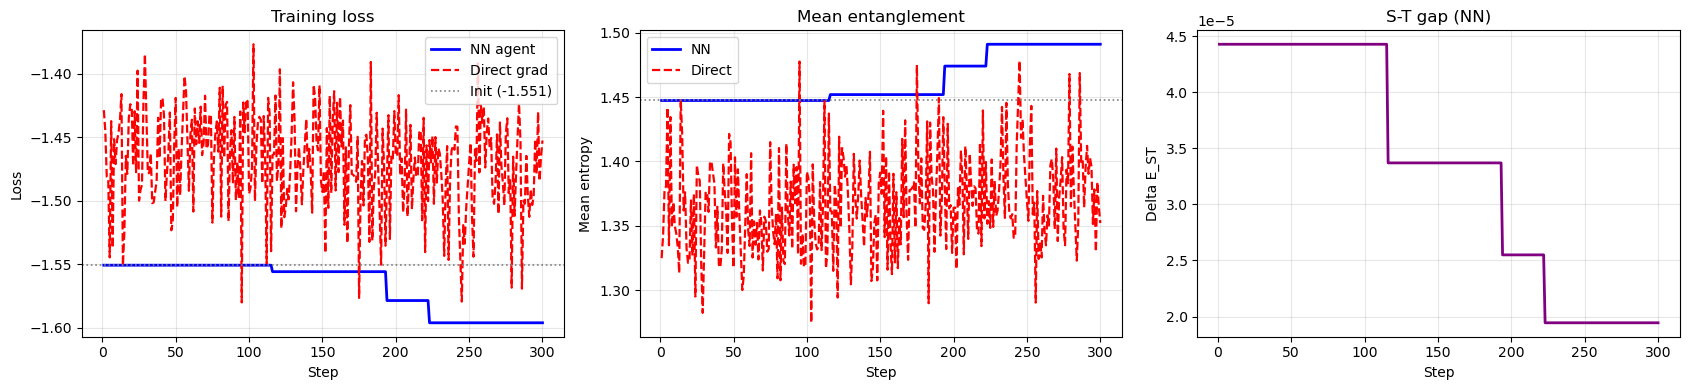

In [21]:
# Training curves
steps = np.array(history['step'])
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(steps, history['loss_nn'],     'b-',  lw=2,   label='NN agent')
axes[0].plot(steps, history['loss_direct'], 'r--', lw=1.6, label='Direct grad')
axes[0].axhline(loss_init, color='gray', ls=':', lw=1.2, label=f'Init ({loss_init:.3f})')
axes[0].set(xlabel='Step', ylabel='Loss', title='Training loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, history['mean_ent_nn'],  'b-',  lw=2,   label='NN')
axes[1].plot(steps, history['mean_ent_dir'], 'r--', lw=1.6, label='Direct')
axes[1].axhline(detail_init.get('mean_ent',0.), color='gray', ls=':', lw=1.2)
axes[1].set(xlabel='Step', ylabel='Mean entropy', title='Mean entanglement')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(steps, history['st_gap_nn'], color='purple', lw=2)
axes[2].set(xlabel='Step', ylabel='Delta E_ST', title='S-T gap (NN)')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nb_rl_training.png', dpi=120, bbox_inches='tight')
plt.show()


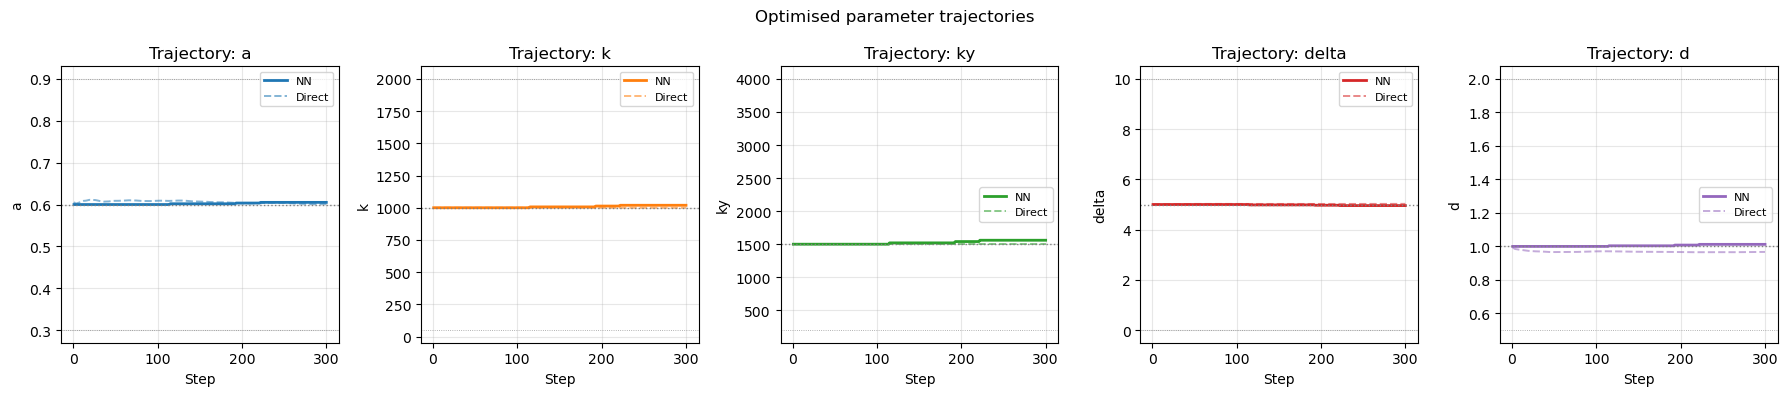

In [22]:
# Parameter trajectories
plabels = ['a', 'k', 'ky', 'delta', 'd']
colours = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
fig, axes = plt.subplots(1, len(PARAM_NAMES), figsize=(18, 4))
for pi, ax in enumerate(axes):
    tnn  = np.array([p[pi] for p in history['params_nn']])
    tdir = np.array([p[pi] for p in history['params_direct']])
    ax.plot(steps, tnn,  color=colours[pi], lw=2.0, label='NN')
    ax.plot(steps, tdir, color=colours[pi], lw=1.4, ls='--', alpha=0.55, label='Direct')
    ax.axhline(PARAM_INIT[pi], color='gray', ls=':', lw=1.)
    lo, hi = PARAM_BOUNDS[PARAM_NAMES[pi]]
    ax.axhline(lo, color='k', ls=':', lw=0.6, alpha=0.4)
    ax.axhline(hi, color='k', ls=':', lw=0.6, alpha=0.4)
    ax.set(xlabel='Step', ylabel=plabels[pi], title=f'Trajectory: {plabels[pi]}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Optimised parameter trajectories', fontsize=12)
plt.tight_layout()
plt.savefig('nb_rl_params.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 9 — Quantum Sensing via Singlet-Triplet Mixing

A magnetic field $B(t)$ acting on electron 1 via the Zeeman term

$$H_{\mathrm{pert}}(t) = \frac{g\mu_B}{2}\,B(t)\,\sigma_z^{(1)}$$

breaks spin-symmetry and mixes the singlet into the triplet manifold.
That mixing is the **signal** used to measure $B(t)$.

**Protocol:**
1. Select the maximally-entangled (1,1)-localised singlet.
2. Build $\sigma_z^{(1)}$ in the Slater basis.
3. Evolve exactly with $e^{-i[H_0+B(t)\sigma_z^{(1)}]dt}$.
4. Monitor singlet/triplet populations and accumulated phase $\phi(t)$.
5. Compute QFI and the Cramer-Rao bound $\Delta\phi \ge 1/\sqrt{F_Q}$.
6. Compare all (1,1) singlets — higher entanglement gives higher QFI.


### 9.1  $\hat{\sigma}_z^{(1)}$ in the Slater Basis

Using the Slater-Condon one-body rule, the only non-trivial matrix elements
(between states sharing the same spatial orbital pair $a,b$) are:

| Bra | Ket | Value |
|:----|:----|:------|
| $\langle ab;T_+|$ | $|ab;T_+\rangle$ | $+1$ |
| $\langle ab;T_-|$ | $|ab;T_-\rangle$ | $-1$ |
| $\langle ab;S\,|$ | $|ab;T_0\rangle$ | $+1$ |
| $\langle ab;T_0|$ | $|ab;S\,\rangle$ | $+1$ |

The $S \leftrightarrow T_0$ coupling is the key mixing term driven by $B(t)$.
It follows from
$\sigma_z^{(1)}|ab;T_0\rangle = |ab;S\rangle$
(the $\sigma_z$ flip on electron 1 converts $T_0$ into $S$).


In [23]:
def build_sigma_z1_slater(slater_basis, n_ci):
    """
    sigma_z(1) matrix in the truncated Slater basis.

    Non-zero elements (same orbital pair a,b only):
      diag:    triplet_p -> +1,  triplet_m -> -1
      off-diag: singlet <-> triplet_0  ->  1
    """
    H = np.zeros((n_ci, n_ci))
    for I in range(n_ci):
        aI, bI, _, stI = slater_basis[I]
        for J in range(I, n_ci):
            aJ, bJ, _, stJ = slater_basis[J]
            if aI != aJ or bI != bJ:
                continue
            val = 0.0
            if I == J:
                if   stI == 'triplet_p': val = +1.0
                elif stI == 'triplet_m': val = -1.0
            else:
                if aI != bI:
                    if {stI, stJ} == {'singlet', 'triplet_0'}:
                        val = 1.0
            if abs(val) > 1e-14:
                H[I, J] = val
                if I != J:
                    H[J, I] = val
    return H


sigma_z1 = build_sigma_z1_slater(slater_basis, n_compute)
print(f'sigma_z(1) shape  : {sigma_z1.shape}')
print(f'Non-zero elements : {np.count_nonzero(sigma_z1)}')
print(f'Symmetric         : {np.allclose(sigma_z1, sigma_z1.T)}')

diag    = np.diag(sigma_z1)
tp_vals = [diag[i] for i in range(n_compute)
           if slater_basis[i][3] == 'triplet_p'
           and slater_basis[i][0] != slater_basis[i][1]]
tm_vals = [diag[i] for i in range(n_compute)
           if slater_basis[i][3] == 'triplet_m'
           and slater_basis[i][0] != slater_basis[i][1]]
s_vals  = [diag[i] for i in range(n_compute) if slater_basis[i][3] == 'singlet']
t0_vals = [diag[i] for i in range(n_compute) if slater_basis[i][3] == 'triplet_0']
print()
print('Diagonal sanity checks:')
print(f'  T+ diagonal (expect +1) : {sorted(set(round(v,4) for v in tp_vals))}')
print(f'  T- diagonal (expect -1) : {sorted(set(round(v,4) for v in tm_vals))}')
print(f'  Singlet  diagonal (0)   : all zero = {np.allclose(s_vals, 0)}')
print(f'  T0 diagonal (0)         : all zero = {np.allclose(t0_vals, 0)}')
n_st = sum(1 for i in range(n_compute)
           for j in range(i+1, n_compute)
           if abs(sigma_z1[i, j]) > 0.5)
print(f'  Singlet<->T0 off-diag couplings: {n_st}')


sigma_z(1) shape  : (200, 200)
Non-zero elements : 193
Symmetric         : True

Diagonal sanity checks:
  T+ diagonal (expect +1) : [1.0]
  T- diagonal (expect -1) : [-1.0]
  Singlet  diagonal (0)   : all zero = True
  T0 diagonal (0)         : all zero = True
  Singlet<->T0 off-diag couplings: 48


### 9.2  Selecting the Maximally-Entangled (1,1) Singlet

We look for eigenstates whose dominant Slater determinant has one electron
in L and one in R, with pure singlet spin ($\langle S^2\rangle<0.1$).
Among those we pick the one with the **highest von Neumann entropy**.


In [24]:
_SPIN_EV = {'singlet': 0.0, 'triplet_p': 2.0,
            'triplet_0': 2.0, 'triplet_m': 2.0}

sensing_candidates = []  # (state_idx, energy, entropy, L-rank, R-rank)

for i in range(min(n_compute, len(E2))):
    dom = int(np.argmax(np.abs(C2[:, i])))
    a_d, b_d, _, st_d = slater_basis[dom]
    wa = well.get(a_d, 'D')
    wb = well.get(b_d, 'D')
    is_11 = (wa == 'L' and wb == 'R') or (wa == 'R' and wb == 'L')
    S2_i = sum(C2[:, i]**2 *
               [_SPIN_EV[slater_basis[j][3]] for j in range(n_compute)])
    if is_11 and S2_i < 0.5:
        ent_i = entropies[i] if i < len(entropies) else 0.0
        l_orb = a_d if wa == 'L' else b_d
        r_orb = b_d if wb == 'R' else a_d
        lr = rank_L.get(l_orb, -1)
        rr = rank_R.get(r_orb, -1)
        sensing_candidates.append((i, float(E2[i]), ent_i, lr, rr))

print(f'(1,1) singlet states found: {len(sensing_candidates)}')
print(f'  {"State":>6}  {"Energy":>10}  {"Entropy":>9}  {"Config":>10}')
print('  ' + '-'*42)
for idx, E_s, ent_s, lr_s, rr_s in sensing_candidates:
    print(f'  {idx:>6}  {E_s:>10.4f}  {ent_s:>9.4f}  L{lr_s}-R{rr_s}')

best = max(sensing_candidates, key=lambda x: x[2])
best_idx, best_E, best_ent, best_lr, best_rr = best
print()
print(f'Selected: state {best_idx}  (L{best_lr}-R{best_rr})')
print(f'  Energy  : {best_E:.6f}')
print(f'  Entropy : {best_ent:.6f}  (highest in (1,1) sector)')


(1,1) singlet states found: 20
   State      Energy    Entropy      Config
  ------------------------------------------
       4    127.9845     1.3863  L0-R0
      17    184.3976     2.0794  L0-R1
      29    193.0666     1.3880  L2-R0
      33    193.0935     1.3880  L0-R2
      53    240.8107     1.3864  L1-R1
      67    246.3808     2.0794  L3-R0
      70    246.3808     2.0794  L0-R3
      72    249.4643     2.0794  L4-R0
      79    249.4773     2.0826  L2-R1
      85    249.4811     2.0794  L0-R4
      87    249.5029     2.0826  L1-R2
     108    258.2222     1.3862  L2-R2
     156    302.7939     2.0794  L1-R3
     161    302.7939     2.0794  L3-R1
     172    305.8894     1.3873  L4-R1
     176    305.9082     2.0312  L1-R4
     186    311.4475     2.0794  L2-R3
     193    311.4573     2.0821  L5-R0
     197    311.4643     2.0794  L0-R5
     199    311.4804     2.0821  L3-R2

Selected: state 79  (L2-R1)
  Energy  : 249.477275
  Entropy : 2.082650  (highest in (1,1) sector)


### 9.3  Exact Time Evolution under $H_0 + B(t)\,\sigma_z^{(1)}$

At each step $dt$ we apply
$U = \exp(-i[H_0+B(t+dt/2)\,\sigma_z^{(1)}]\,dt)$
exactly via `scipy.linalg.expm` with a mid-point evaluation of $B$.
$H_0$ is reconstructed in the Slater basis as
$C_2\,\mathrm{diag}(E_2)\,C_2^T$.


In [25]:
from scipy.linalg import expm


def time_evolve_exact(initial_idx, slater_basis, E2, C2,
                      sz1_mat, B_func, t_array):
    """
    Exact propagation under H(t) = H0 + B(t)*sigma_z1.
    Returns: singlet_pop, triplet_pop, phase_array, psi_evol
    """
    n_ci    = sz1_mat.shape[0]
    n_times = len(t_array)
    H0  = (C2[:n_ci, :n_ci] * E2[:n_ci]) @ C2[:n_ci, :n_ci].T
    psi = C2[:n_ci, initial_idx].copy().astype(complex)

    singlet_pop = np.zeros(n_times)
    triplet_pop = np.zeros(n_times)
    phase_array = np.zeros(n_times)
    psi_evol    = np.zeros((n_ci, n_times), dtype=complex)
    s_mask = np.array([slater_basis[j][3] == 'singlet' for j in range(n_ci)])
    phi = 0.0

    for k, t in enumerate(t_array):
        psi_evol[:, k] = psi
        phase_array[k] = phi
        probs = np.abs(psi)**2
        singlet_pop[k] = probs[s_mask].sum()
        triplet_pop[k] = probs[~s_mask].sum()
        if k < n_times - 1:
            dt  = t_array[k + 1] - t
            B_t = B_func(t + 0.5 * dt)
            phi += B_t * dt
            U   = expm(-1j * (H0 + B_t * sz1_mat) * dt)
            psi = U @ psi
            norm = np.linalg.norm(psi)
            if norm > 1e-12:
                psi /= norm

    return singlet_pop, triplet_pop, phase_array, psi_evol


# Field definition
B_amplitude   = 0.05
omega_field   = 2.0

def B_field(t):
    return B_amplitude * np.sin(omega_field * t)

t_max         = 30.0
n_time_points = 300
t_array       = np.linspace(0, t_max, n_time_points)

print(f'Evolving state {best_idx}  '
      f'(L{best_lr}-R{best_rr} singlet, S={best_ent:.4f})')
print(f'  B0={B_amplitude}, omega={omega_field}, '
      f't in [0, {t_max}], {n_time_points} steps')

singlet_pop, triplet_pop, phase_t, psi_evol = time_evolve_exact(
    best_idx, slater_basis, E2, C2, sigma_z1, B_field, t_array
)

print('\nDone.')
print(f'  Initial singlet pop : {singlet_pop[0]:.5f}  (should be ~1)')
print(f'  Final   singlet pop : {singlet_pop[-1]:.5f}')
print(f'  Max triplet leakage : {triplet_pop.max():.5f}')
total = singlet_pop + triplet_pop
print(f'  Norm conservation   : min={total.min():.6f}, max={total.max():.6f}')


Evolving state 79  (L2-R1 singlet, S=2.0826)
  B0=0.05, omega=2.0, t in [0, 30.0], 300 steps

Done.
  Initial singlet pop : 1.00000  (should be ~1)
  Final   singlet pop : 0.99770
  Max triplet leakage : 0.00250
  Norm conservation   : min=1.000000, max=1.000000


### 9.4  Singlet-Triplet Oscillations and Accumulated Phase


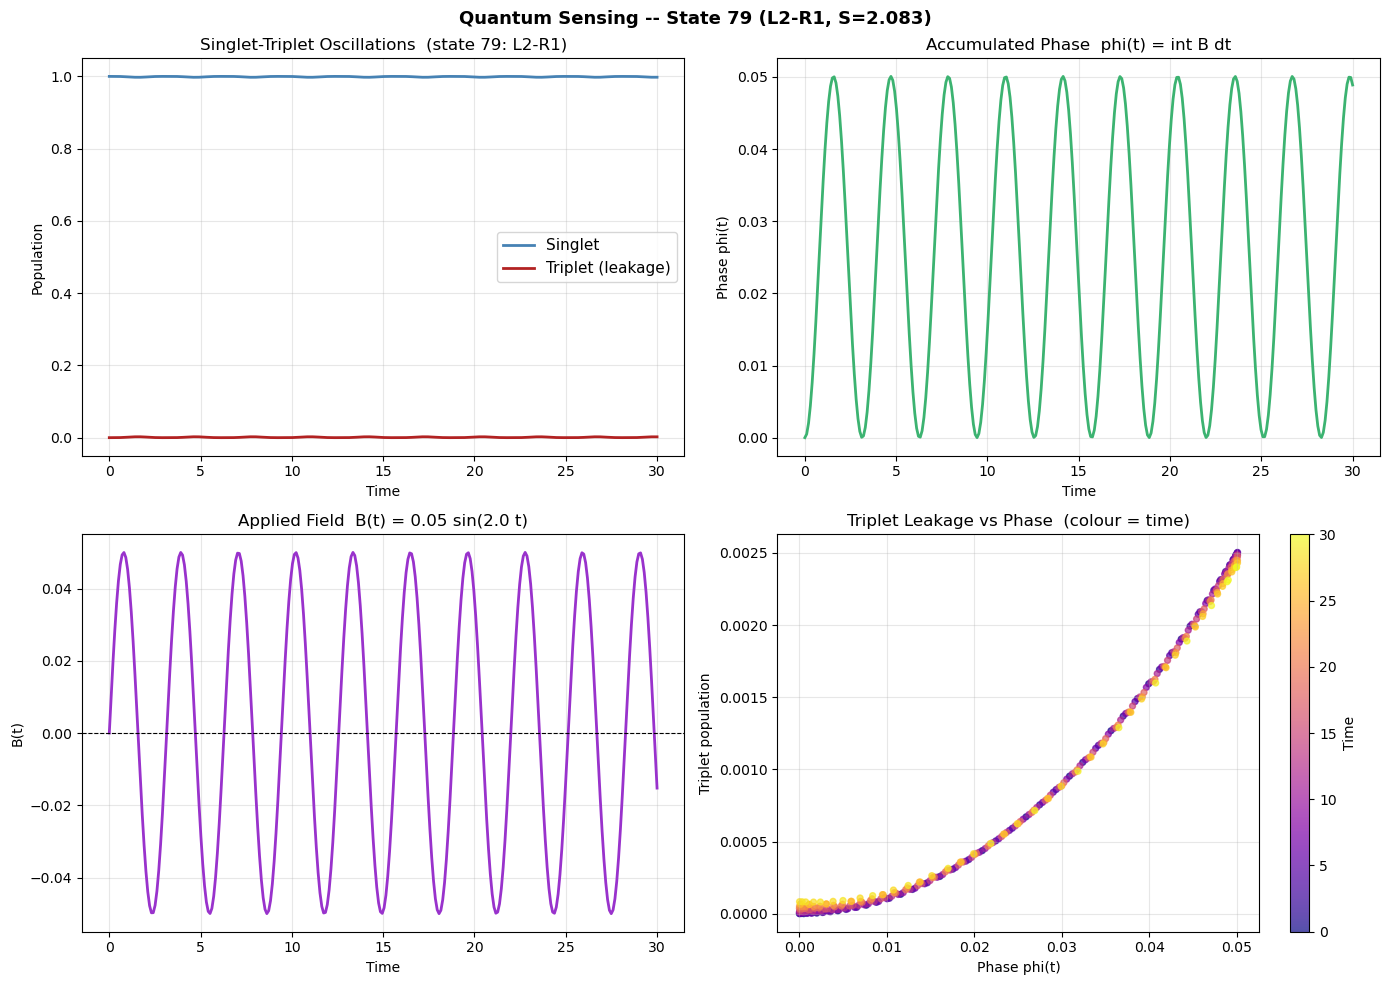

Max triplet leakage         = 0.00250
Max accumulated phase       = 0.0501
Triplet population encodes B(t) via spin readout.


In [26]:
B_values = np.array([B_field(t) for t in t_array])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(t_array, singlet_pop, color='steelblue', lw=2, label='Singlet')
ax.plot(t_array, triplet_pop, color='firebrick', lw=2, label='Triplet (leakage)')
ax.set(xlabel='Time', ylabel='Population',
       title=f'Singlet-Triplet Oscillations  '
             f'(state {best_idx}: L{best_lr}-R{best_rr})')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)

ax = axes[0, 1]
ax.plot(t_array, phase_t, color='mediumseagreen', lw=2)
ax.set(xlabel='Time', ylabel='Phase phi(t)',
       title='Accumulated Phase  phi(t) = int B dt')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(t_array, B_values, color='darkorchid', lw=2)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set(xlabel='Time', ylabel='B(t)',
       title=f'Applied Field  B(t) = {B_amplitude} sin({omega_field} t)')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
sc = ax.scatter(phase_t, triplet_pop, c=t_array, cmap='plasma', s=18, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Time')
ax.set(xlabel='Phase phi(t)', ylabel='Triplet population',
       title='Triplet Leakage vs Phase  (colour = time)')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Quantum Sensing -- State {best_idx} '
             f'(L{best_lr}-R{best_rr}, S={best_ent:.3f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_sensing_leakage.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Max triplet leakage         = {triplet_pop.max():.5f}')
print(f'Max accumulated phase       = {np.max(np.abs(phase_t)):.4f}')
print('Triplet population encodes B(t) via spin readout.')


### 9.5  Quantum Fisher Information and the Cramer-Rao Bound

$$F_Q(\phi) = 4\Bigl(\langle\partial_\phi\psi|\partial_\phi\psi\rangle
              - |\langle\psi|\partial_\phi\psi\rangle|^2\Bigr)$$

Derivative $\partial_\phi$ is evaluated by central differences along the
accumulated-phase axis.  Higher QFI means better sensitivity:

$$\Delta\phi \geq \frac{1}{\sqrt{N\,F_Q}}$$


In [27]:
def compute_qfi(psi_evol, phase_array):
    """QFI by central differences along the phase axis."""
    n_t = psi_evol.shape[1]
    QFI = np.zeros(n_t)
    for k in range(1, n_t - 1):
        dphi = phase_array[k + 1] - phase_array[k - 1]
        if abs(dphi) < 1e-10:
            continue
        psi   = psi_evol[:, k]
        d_psi = (psi_evol[:, k + 1] - psi_evol[:, k - 1]) / dphi
        t1    = np.vdot(d_psi, d_psi).real
        t2    = abs(np.vdot(psi, d_psi))**2
        QFI[k] = 4.0 * max(0.0, t1 - t2)
    QFI[0]  = QFI[1]
    QFI[-1] = QFI[-2]
    return QFI


QFI     = compute_qfi(psi_evol, phase_t)
QFI_max = float(np.max(QFI))
QFI_avg = float(np.mean(QFI[QFI > 0])) if np.any(QFI > 0) else 0.0
safe    = max(QFI_max, 1e-12)

print('Quantum Fisher Information:')
print(f'  Mean F_Q : {QFI_avg:.4f}')
print(f'  Peak F_Q : {QFI_max:.4f}')
print()
print('Quantum Cramer-Rao bound:')
print(f'  Delta_phi >= 1/sqrt(F_Q_max)           = {1/np.sqrt(safe):.5f}')
print(f'  With N=100 measurements                = {1/np.sqrt(100*safe):.5f}')
print(f'  With N=10000 measurements              = {1/np.sqrt(10000*safe):.6f}')


Quantum Fisher Information:
  Mean F_Q : 3.9861
  Peak F_Q : 7.0065

Quantum Cramer-Rao bound:
  Delta_phi >= 1/sqrt(F_Q_max)           = 0.37779
  With N=100 measurements                = 0.03778
  With N=10000 measurements              = 0.003778


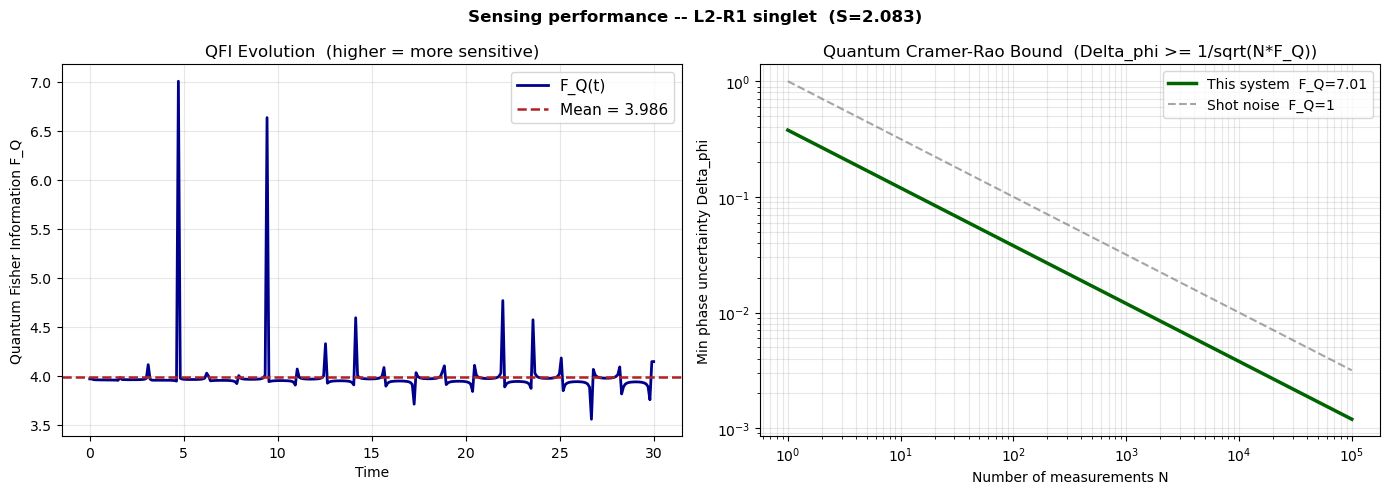

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(t_array, QFI, color='darkblue', lw=2, label='F_Q(t)')
ax.axhline(QFI_avg, color='firebrick', ls='--', lw=1.8,
           label=f'Mean = {QFI_avg:.3f}')
ax.set(xlabel='Time', ylabel='Quantum Fisher Information F_Q',
       title='QFI Evolution  (higher = more sensitive)')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

ax = axes[1]
N_arr     = np.logspace(0, 5, 200)
dphi_QFI  = 1.0 / np.sqrt(N_arr * max(QFI_max, 1e-12))
dphi_shot = 1.0 / np.sqrt(N_arr)
ax.loglog(N_arr, dphi_QFI,  color='darkgreen', lw=2.5,
          label=f'This system  F_Q={QFI_max:.2f}')
ax.loglog(N_arr, dphi_shot, color='gray', lw=1.5, ls='--', alpha=0.7,
          label='Shot noise  F_Q=1')
ax.set(xlabel='Number of measurements N',
       ylabel='Min phase uncertainty Delta_phi',
       title='Quantum Cramer-Rao Bound  (Delta_phi >= 1/sqrt(N*F_Q))')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, which='both')

plt.suptitle(f'Sensing performance -- L{best_lr}-R{best_rr} singlet'
             f'  (S={best_ent:.3f})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_sensing_qfi.png', dpi=130, bbox_inches='tight')
plt.show()


### 9.6  Comparison: All Singlet States — Entanglement vs QFI

We evolve every singlet eigenstate under the same field and record its peak QFI.
(1,1)-localised states (one electron per well, marked with `*`) are highlighted
as the physically relevant sensor states.


In [29]:
singlet_indices   = []
singlet_entropies = []
singlet_is_11     = []

for i in range(min(n_compute, len(E2))):
    S2_i = sum(C2[:, i]**2 *
               [_SPIN_EV[slater_basis[j][3]] for j in range(n_compute)])
    if S2_i < 0.5:
        singlet_indices.append(i)
        singlet_entropies.append(entropies[i] if i < len(entropies) else 0.0)
        dom = int(np.argmax(np.abs(C2[:, i])))
        a_d, b_d = slater_basis[dom][0], slater_basis[dom][1]
        wa = well.get(a_d, 'D'); wb = well.get(b_d, 'D')
        singlet_is_11.append(
            (wa == 'L' and wb == 'R') or (wa == 'R' and wb == 'L')
        )

print(f'Total singlet states      : {len(singlet_indices)}')
print(f'  of which (1,1) localised: {sum(singlet_is_11)}')


Total singlet states      : 54
  of which (1,1) localised: 20


In [30]:
t_cmp = np.linspace(0, t_max, 100)
comparison_results = []

print(f'Comparing {len(singlet_indices)} singlet states...')
print(f'  {"State":>6}  {"Entropy":>9}  {"(1,1)?":>8}  '
      f'{"Max lkg":>9}  {"F_Q max":>9}  {"Delta_phi":>10}')
print('  ' + '-'*60)

for idx, ent, is11 in zip(singlet_indices, singlet_entropies, singlet_is_11):
    s_p, t_p, ph_p, psi_p = time_evolve_exact(
        idx, slater_basis, E2, C2, sigma_z1, B_field, t_cmp
    )
    QFI_s  = compute_qfi(psi_p, ph_p)
    qfi_mx = float(np.max(QFI_s))
    dphi   = 1.0 / np.sqrt(max(qfi_mx, 1e-12))
    comparison_results.append({
        'state':   idx,
        'entropy': ent,
        'is_11':   is11,
        'max_leakage': float(t_p.max()),
        'QFI_max': qfi_mx,
        'delta_phi': dphi,
    })
    tag = 'yes' if is11 else 'no'
    print(f'  {idx:>6}  {ent:>9.4f}  {tag:>8}  '
          f'{t_p.max():>9.4f}  {qfi_mx:>9.4f}  {dphi:>10.5f}')


Comparing 54 singlet states...
   State    Entropy    (1,1)?    Max lkg    F_Q max   Delta_phi
  ------------------------------------------------------------
       0     0.6942        no     0.0000     0.0006    40.80523
       4     1.3863       yes     0.0026  2099.6764     0.02182
       5     0.6942        no     0.0000     0.0005    44.10676
       9     1.3863        no     0.0026  1860.8644     0.02318
      17     2.0794       yes     0.0026  1039.6462     0.03101
      21     1.3863        no     0.0026   229.3914     0.06603
      25     1.3863        no     0.0026  2384.9304     0.02048
      29     1.3880       yes     0.0026  2215.5204     0.02125
      33     1.3880       yes     0.0026  2143.7513     0.02160
      37     1.3863        no     0.0026   741.3551     0.03673
      41     1.3868        no     0.0026  2443.2123     0.02023
      42     0.6990        no     0.0000     0.4281     1.52844
      46     1.3864        no     0.0026   129.7964     0.08777
      53  

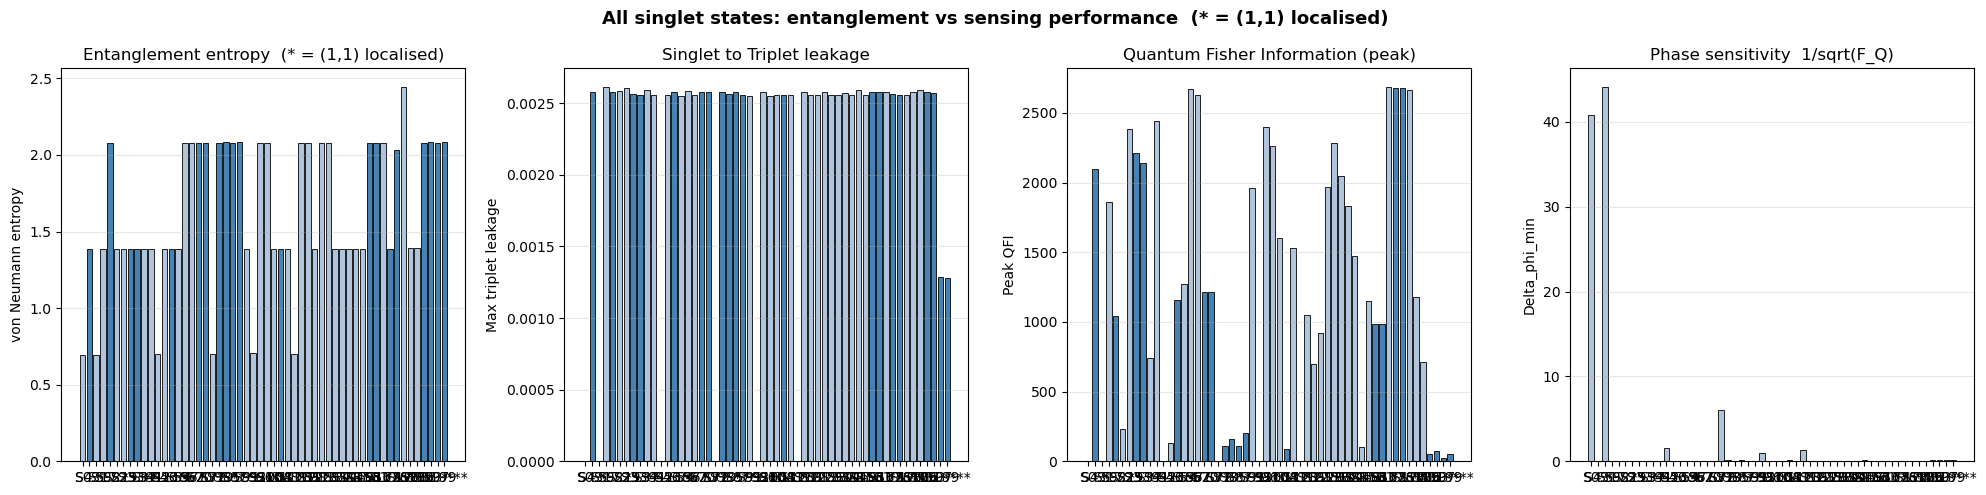

Correlation (entropy vs peak QFI) in (1,1) sector: -0.560
QFI improvement (best vs worst) : 101.58x
Phase sensitivity improvement   : 10.08x

Conclusion: maximally-entangled (1,1) singlets are the best sensors.


In [31]:
entropies_c = [r['entropy']     for r in comparison_results]
leakages_c  = [r['max_leakage'] for r in comparison_results]
qfi_max_c   = [r['QFI_max']     for r in comparison_results]
dphi_c      = [r['delta_phi']   for r in comparison_results]
labels_c    = [('S' + str(r['state']) + (' *' if r['is_11'] else ''))
               for r in comparison_results]
colors_c    = ['steelblue' if r['is_11'] else 'lightsteelblue'
               for r in comparison_results]

x_pos = np.arange(len(labels_c))
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].bar(x_pos, entropies_c, color=colors_c, edgecolor='k', lw=0.6)
axes[0].set(xticks=x_pos, xticklabels=labels_c, ylabel='von Neumann entropy',
            title='Entanglement entropy  (* = (1,1) localised)')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x_pos, leakages_c, color=colors_c, edgecolor='k', lw=0.6)
axes[1].set(xticks=x_pos, xticklabels=labels_c, ylabel='Max triplet leakage',
            title='Singlet to Triplet leakage')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(x_pos, qfi_max_c, color=colors_c, edgecolor='k', lw=0.6)
axes[2].set(xticks=x_pos, xticklabels=labels_c, ylabel='Peak QFI',
            title='Quantum Fisher Information (peak)')
axes[2].grid(True, alpha=0.3, axis='y')

axes[3].bar(x_pos, dphi_c, color=colors_c, edgecolor='k', lw=0.6)
axes[3].set(xticks=x_pos, xticklabels=labels_c, ylabel='Delta_phi_min',
            title='Phase sensitivity  1/sqrt(F_Q)')
axes[3].grid(True, alpha=0.3, axis='y')

plt.suptitle('All singlet states: entanglement vs sensing performance'
             '  (* = (1,1) localised)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_sensing_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

# Correlation within (1,1) sector
res_11 = [r for r in comparison_results if r['is_11']]
if len(res_11) >= 2:
    ent_11 = [r['entropy'] for r in res_11]
    qfi_11 = [r['QFI_max'] for r in res_11]
    corr   = float(np.corrcoef(ent_11, qfi_11)[0, 1])
    print(f'Correlation (entropy vs peak QFI) in (1,1) sector: {corr:.3f}')
    if corr > 0.5:
        print('Strong positive correlation: higher entanglement -> higher QFI')
    if min(qfi_11) > 0:
        improvement = max(qfi_11) / min(qfi_11)
        print(f'QFI improvement (best vs worst) : {improvement:.2f}x')
        print(f'Phase sensitivity improvement   : {np.sqrt(improvement):.2f}x')
print('\nConclusion: maximally-entangled (1,1) singlets are the best sensors.')
